# Week 6, PINN Mandel Problem

PINN solver for Mandel's poroelasticity problem using sequential stress-split training
Check out the paper for more details: Physics-informed neural network simulation of multiphase poroelasticity using stress-split sequential training

Find the paper at: https://arxiv.org/abs/2110.03049

In [1]:
import numpy as np
import torch
import torch.nn as nn
import os, time
import matplotlib.pyplot as plt
import time
from scipy.optimize import fsolve

In [2]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

CUDA available: True
GPU name: Tesla T4
Using device: cuda


In [3]:
# Unit conversions
s, minute, hr, day = 1., 60., 60.**2, 24*60.**2
g, kg = 1.e-3, 1.
mm, cm, m, km = 1e-3, 1e-2, 1.0, 1e3
Pa, kPa, MPa, GPa = 1.0, 1.e3, 1.e6, 1.e9
micro, milli, centi, kilo, mega = 1e-6, 1e-3, 1e-2, 1e3, 1e6
poise = 0.1*Pa*s
Darcy = 9.869233e-13*m**2

In [4]:
#----------parameters-----------
DTYPE = 'float32'

S_overburden = -2*MPa
rho_b = 2400.0 * kg/m**3
rho_f = 1000. * kg/m**3
mu = 6. * milli * poise
k = 1e-12
E = 120e6
nu = 0.25
b = 1.0
M = 120e6
Lx = 50*m
Ly = 10*m

Kdr = E/(3*(1-2*nu))
B = (b*M)/(Kdr+M*(b**2))
nu_u = (3*nu+b*B*(1-2*nu))/(3-b*B*(1-2*nu))
F = S_overburden*Ly*1*m
Gshr = E/2/(1+nu)
Gama = B*(1+nu_u)/(3*(1-nu_u))
p0 = (-F)*B*(1+nu_u)/(3*Ly)

p_star = p0
x_star = Ly
t_star = (b**2/Kdr + 1/M)*mu*(x_star**2)/(k) #
nu_star = (1 - 2*nu)/(1 + nu)
u_star = p_star*x_star/Kdr
D_star = b*M/((b**2)*M + Kdr)
print("D_star = "+str(D_star)+",\np0 = "+str(p0/MPa)+" (MPa)")

D_star = 0.6,
p0 = 0.5555555555555555 (MPa)


In [21]:
# ----------------------- Neural Network Setup -----------------------
torch.manual_seed(142) #sn.reset_session()
#sn.set_random_seed(124)

class Functional(nn.Module):
  def __init__(self):
    super(Functional, self).__init__()
    self.NN = nn.Sequential(
        nn.Linear(3,40),
        nn.Tanh(),
        nn.Linear(40,40),
        nn.Tanh(),
        nn.Linear(40,40),
        nn.Tanh(),
        nn.Linear(40,40),
        nn.Tanh(),
        nn.Linear(40,1)
    )

  def forward(self, x, y, t):
    inputs = torch.cat([x,y,t], dim=1)
    return self.NN(inputs)


model_pd = Functional().to(device)
model_ud = Functional().to(device)
model_vd = Functional().to(device)


In [22]:
td_0 = 0.0
td_f = 1000/t_star
xd_min = 0.0
xd_max = (Lx/x_star)
yd_min = 0.0
yd_max = (Ly/x_star)


In [23]:
def sample_points():#n_total
  # n_point = int(n_total/6)
  n_p_dom = 20  #int(n_point**0.36)
  n_p_bcic = 200 #int(n_point**0.5)

  X = xd_min + (xd_max-xd_min)* torch.linspace(0,1,n_p_dom, device=device) #torch.rand(n_p_dom, device=device)
  Y = yd_min + (yd_max-yd_min)* torch.linspace(0,1,n_p_dom, device=device) #torch.rand(n_p_dom, device=device)
  T = td_0 + (td_f-td_0)* torch.linspace(0,1,101, device=device)#torch.rand(n_p_dom, device=device)
  xd_phys, yd_phys, td_phys = torch.meshgrid(X[1:-1], Y[1:-1], T[1:], indexing="ij")

  xd_dom = xd_phys.reshape(-1,1).clone().detach().requires_grad_(True)
  yd_dom = yd_phys.reshape(-1,1).clone().detach().requires_grad_(True)
  td_dom = td_phys.reshape(-1,1).clone().detach().requires_grad_(True)

  X_BCIC = xd_min + (xd_max-xd_min)* torch.linspace(0,1,n_p_bcic, device=device)#* torch.rand(n_p_bcic, device=device)
  Y_BCIC = yd_min + (yd_max-yd_min)* torch.linspace(0,1,n_p_bcic, device=device)#* torch.rand(n_p_bcic, device=device)
  T_BCIC = td_0 + (td_f-td_0)* torch.linspace(0,1,n_p_bcic, device=device)#* torch.rand(n_p_bcic, device=device)

  # --- ic points --- #
  td_ic_points = torch.tensor([td_0], device=device)
  xd_icp, yd_icp, td_icp = torch.meshgrid(X_BCIC[1:-1], Y_BCIC[1:-1], td_ic_points, indexing="ij")
  xd_ic = xd_icp.reshape(-1,1).clone().detach().requires_grad_(True)
  yd_ic = yd_icp.reshape(-1,1).clone().detach().requires_grad_(True)
  td_ic = td_icp.reshape(-1,1).clone().detach().requires_grad_(True)

  # --- bc-left points --- #
  xd_bcl_points = torch.tensor([xd_min], device=device)
  xd_bclp, yd_bclp, td_bclp = torch.meshgrid(xd_bcl_points, Y_BCIC[1:-1], T_BCIC[1:], indexing="ij")
  xd_bcl = xd_bclp.reshape(-1,1).clone().detach().requires_grad_(True)
  yd_bcl = yd_bclp.reshape(-1,1).clone().detach().requires_grad_(True)
  td_bcl = td_bclp.reshape(-1,1).clone().detach().requires_grad_(True)

  # --- bc-right points --- #
  xd_bcr_points = torch.tensor([xd_max], device=device)
  xd_bcrp, yd_bcrp, td_bcrp = torch.meshgrid(xd_bcr_points, Y_BCIC[1:-1], T_BCIC[1:], indexing="ij")
  xd_bcr = xd_bcrp.reshape(-1,1).clone().detach().requires_grad_(True)
  yd_bcr = yd_bcrp.reshape(-1,1).clone().detach().requires_grad_(True)
  td_bcr = td_bcrp.reshape(-1,1).clone().detach().requires_grad_(True)

  # --- bc-bot points --- #
  yd_bcb_points = torch.tensor([yd_min], device=device)
  xd_bcbp, yd_bcbp, td_bcbp = torch.meshgrid(X_BCIC[1:-1], yd_bcb_points, T_BCIC[1:], indexing="ij")
  xd_bcb = xd_bcbp.reshape(-1,1).clone().detach().requires_grad_(True)
  yd_bcb = yd_bcbp.reshape(-1,1).clone().detach().requires_grad_(True)
  td_bcb = td_bcbp.reshape(-1,1).clone().detach().requires_grad_(True)

  # --- bc-top points --- #
  yd_bct_points = torch.tensor([yd_max], device=device)
  xd_bctp, yd_bctp, td_bctp = torch.meshgrid(X_BCIC[1:-1], yd_bct_points, T_BCIC[1:], indexing="ij")
  xd_bct = xd_bctp.reshape(-1,1).clone().detach().requires_grad_(True)
  yd_bct = yd_bctp.reshape(-1,1).clone().detach().requires_grad_(True)
  td_bct = td_bctp.reshape(-1,1).clone().detach().requires_grad_(True)

  return xd_dom, yd_dom, td_dom, xd_ic, yd_ic, td_ic, xd_bcr, yd_bcr, td_bcr, xd_bcl, yd_bcl, td_bcl, xd_bcb, yd_bcb, td_bcb, xd_bct, yd_bct, td_bct

In [24]:
def All_Derivatives(xd_dom, yd_dom, td_dom, xd_ic, yd_ic, td_ic, xd_bcr, yd_bcr, td_bcr, xd_bcl, yd_bcl, td_bcl, xd_bcb, yd_bcb, td_bcb, xd_bct, yd_bct, td_bct):
  def grad_cal(y, x):
    grad = torch.autograd.grad(y, x, torch.ones_like(y), retain_graph=True, create_graph=True)[0]
    if grad is None:
      grad = torch.zeros_like(y)
    return grad

  pd_dom = model_pd(xd_dom, yd_dom, td_dom)
  ud_dom = model_ud(xd_dom, yd_dom, td_dom)
  vd_dom = model_vd(xd_dom, yd_dom, td_dom)
  Evd_dom = grad_cal(ud_dom, xd_dom) + grad_cal(vd_dom,yd_dom)  #model_Evd(xd_dom, yd_dom, td_dom)

  pd_ic = model_pd(xd_ic, yd_ic, td_ic)
  ud_ic = model_ud(xd_ic, yd_ic, td_ic)
  vd_ic = model_vd(xd_ic, yd_ic, td_ic)
  Evd_ic = grad_cal(ud_ic, xd_ic) + grad_cal(vd_ic,yd_ic)

  pd_bcr = model_pd(xd_bcr, yd_bcr, td_bcr)
  ud_bcr = model_ud(xd_bcr, yd_bcr, td_bcr)
  vd_bcr = model_vd(xd_bcr, yd_bcr, td_bcr)
  Evd_bcr = grad_cal(ud_bcr, xd_bcr) + grad_cal(vd_bcr,yd_bcr)

  pd_bcl = model_pd(xd_bcl, yd_bcl, td_bcl)
  ud_bcl = model_ud(xd_bcl, yd_bcl, td_bcl)
  vd_bcl = model_vd(xd_bcl, yd_bcl, td_bcl)
  Evd_bcl = grad_cal(ud_bcl, xd_bcl) + grad_cal(vd_bcl,yd_bcl)

  pd_bcb = model_pd(xd_bcb, yd_bcb, td_bcb)
  ud_bcb = model_ud(xd_bcb, yd_bcb, td_bcb)
  vd_bcb = model_vd(xd_bcb, yd_bcb, td_bcb)
  Evd_bcb = grad_cal(ud_bcb, xd_bcb) + grad_cal(vd_bcb,yd_bcb)

  pd_bct = model_pd(xd_bct, yd_bct, td_bct)
  ud_bct = model_ud(xd_bct, yd_bct, td_bct)
  vd_bct = model_vd(xd_bct, yd_bct, td_bct)
  Evd_bct = grad_cal(ud_bct, xd_bct) + grad_cal(vd_bct,yd_bct)


  Sxxd_ic = (1-nu_star)*Evd_ic + 3*nu_star*grad_cal(ud_ic, xd_ic) - b*(pd_ic)
  Syyd_ic = (1-nu_star)*Evd_ic + 3*nu_star*grad_cal(vd_ic, yd_ic) - b*(pd_ic)
  Sxxd_bcl = (1-nu_star)*Evd_bcl + 3*nu_star*grad_cal(ud_bcl, xd_bcl) - b*(pd_bcl)
  Syyd_bct = (1-nu_star)*Evd_bct + 3*nu_star*grad_cal(vd_bct, yd_bct) - b*(pd_bct)

  Sxyd_bcr = 3*nu_star*0.5*(grad_cal(ud_bcr,yd_bcr)+grad_cal(vd_bcr,xd_bcr))
  Sxyd_bcl = 3*nu_star*0.5*(grad_cal(ud_bcl,yd_bcl)+grad_cal(vd_bcl,xd_bcl))
  Sxyd_bct = 3*nu_star*0.5*(grad_cal(ud_bct,yd_bct)+grad_cal(vd_bct,xd_bct))
  Sxyd_bcb = 3*nu_star*0.5*(grad_cal(ud_bcb,yd_bcb)+grad_cal(vd_bcb,xd_bcb))

  Svd_dom = Evd_dom - b*(pd_dom)
  Svd_td_dom = grad_cal(Svd_dom, td_dom)

  return pd_dom, pd_ic, pd_bcr, pd_bcl, pd_bcb, pd_bct, ud_dom, vd_dom, Evd_dom, Sxxd_ic, Syyd_ic, Sxxd_bcl, ud_bcr, Sxyd_bcb, Sxyd_bct, Sxyd_bcl, Sxyd_bcr, vd_bcb, Syyd_bct, Svd_td_dom



In [25]:
# --- weight and last layer definition for GN --- #
LL_pd = model_pd.NN[-1].weight
W_F_Eq = torch.nn.Parameter(torch.tensor([1.0], device=device))
W_F_ic = torch.nn.Parameter(torch.tensor([1.0], device=device))
W_F_bcr = torch.nn.Parameter(torch.tensor([1.0], device=device))
W_F_bcl = torch.nn.Parameter(torch.tensor([1.0], device=device))
W_F_bct = torch.nn.Parameter(torch.tensor([1.0], device=device))
W_F_bcb = torch.nn.Parameter(torch.tensor([1.0], device=device))

LL_ud = model_ud.NN[-1].weight
LL_vd = model_vd.NN[-1].weight
W_S_u_Eq = torch.nn.Parameter(torch.tensor([1.0], device=device))
W_S_v_Eq = torch.nn.Parameter(torch.tensor([1.0], device=device))
W_S_IC_Sxx = torch.nn.Parameter(torch.tensor([1.0], device=device))
W_S_IC_Syy = torch.nn.Parameter(torch.tensor([1.0], device=device))
W_S_BCL_u = torch.nn.Parameter(torch.tensor([1.0], device=device))
W_S_BCR_u = torch.nn.Parameter(torch.tensor([1.0], device=device))
W_S_BCB_u = torch.nn.Parameter(torch.tensor([1.0], device=device))
W_S_BCT_u = torch.nn.Parameter(torch.tensor([1.0], device=device))
W_S_BCL_v = torch.nn.Parameter(torch.tensor([1.0], device=device))
W_S_BCR_v = torch.nn.Parameter(torch.tensor([1.0], device=device))
W_S_BCB_v = torch.nn.Parameter(torch.tensor([1.0], device=device))
W_S_BCT_v = torch.nn.Parameter(torch.tensor([1.0], device=device))

In [26]:
def plot_function(His_L_F, His_L_S, model_pd, model_ud, model_vd):
  # loss plot
  fig, ax = plt.subplots(2,1, figsize=(9,5))
  ax[0].semilogy(His_L_F)
  ax[1].semilogy(His_L_S)
  ax[0].set_xlabel("Epochs"), ax[1].set_xlabel("Epochs")
  ax[0].set_ylabel("Loss")
  ax[0].set_title("Fluid"), ax[1].set_title("Solid")
  ax[0].grid(ls='--', alpha=0.25), ax[1].grid(ls='--', alpha=0.25)
  plt.subplots_adjust(wspace=0.35, hspace=0.55)
  plt.show()

  # --- plot solution --- #
  xs_p_line = torch.tensor([xd_max], device=device)
  ys_p_line = torch.linspace(yd_min, yd_max, 50, device=device)
  ts_p_line = torch.tensor([td_f*0.01, td_f*0.025, td_f*0.05,td_f*0.1, td_f*0.25, td_f*0.5, td_f*0.75, td_f*1.0], device=device)   #
  X_P_plot, Y_P_plot, T_P_plot = torch.meshgrid(xs_p_line, ys_p_line, ts_p_line, indexing='ij')
  X_P_plot = X_P_plot.reshape(-1,1)
  Y_P_plot = Y_P_plot.reshape(-1,1)
  T_P_plot = T_P_plot.reshape(-1,1)
  input_test_p_line = np.meshgrid(xs_p_line.detach().cpu().numpy(), ys_p_line.detach().cpu().numpy(), ts_p_line.detach().cpu().numpy(), indexing='ij')



  xs_u_line = torch.linspace(xd_min, xd_max, 50, device=device)
  ys_u_line = torch.tensor([yd_max], device=device)
  ts_u_line = torch.tensor([td_f*0.01, td_f*0.025, td_f*0.05,td_f*0.1, td_f*0.25, td_f*0.5, td_f*0.75, td_f*1.0], device=device)   #
  X_U_plot, Y_U_plot, T_U_plot = torch.meshgrid(xs_u_line, ys_u_line, ts_u_line, indexing='ij')
  X_U_plot = X_U_plot.reshape(-1,1)
  Y_U_plot = Y_U_plot.reshape(-1,1)
  T_U_plot = T_U_plot.reshape(-1,1)
  input_test_u_line = np.meshgrid(xs_u_line.detach().cpu().numpy(), ys_u_line.detach().cpu().numpy(), ts_u_line.detach().cpu().numpy(), indexing='ij')
  # --- PINN solution --- #
  with torch.no_grad():
    pd_plot = model_pd(X_P_plot, Y_P_plot, T_P_plot)
    ud_plot = model_ud(X_U_plot, Y_U_plot, T_U_plot)
    vd_plot = model_vd(X_P_plot, Y_P_plot, T_P_plot)

  p_plot = p_star*pd_plot.reshape(len(xs_p_line), len(ys_p_line), len(ts_p_line))
  u_plot = u_star*ud_plot.reshape(len(xs_u_line), len(ys_u_line), len(ts_u_line))
  v_plot = u_star*vd_plot.reshape(len(xs_p_line), len(ys_p_line), len(ts_p_line))

  ys_p_np = ys_p_line.detach().cpu().numpy()
  xs_u_np = xs_u_line.detach().cpu().numpy()
  ts_p_np = ts_p_line.detach().cpu().numpy()

  p_plot_np = p_plot.detach().cpu().numpy()
  u_plot_np = u_plot.detach().cpu().numpy()
  v_plot_np = v_plot.detach().cpu().numpy()

  # ---- analytical solution ---- #
  def func(z):
      return np.tan(z) - ((1-nu)/(nu_u-nu))*z

  a = np.around((np.linspace(1, 100, 100)*2-1)*(np.pi/2)*0.999999834, decimals=6)
  roots = np.zeros_like(a)
  residual = np.zeros_like(a)
  for i in range(100):
      roots[i] = fsolve(func, a[i])
      residual[i] = np.tan(roots[i]) - ((1-nu)/(nu_u-nu))*roots[i]
  ###------pressure------
  p_true_line = np.zeros_like(input_test_p_line[1])

  for i in range(100):
      alpha = roots[i]
      T1 = np.sin(alpha)/(alpha-np.sin(alpha)*np.cos(alpha))
      T2 = np.cos(alpha * (input_test_p_line[1])) - np.cos(alpha)
      T3 = np.exp(-(alpha**2) * input_test_p_line[2])
      p_true_line += T1 * T2 * T3

  term1=2*(-F)*B*(1+nu_u)/(3*Ly)
  p_true_line = term1*p_true_line/MPa

  ###-----vertical displacement------
  v_true_part1 = np.zeros_like(input_test_p_line[2])
  v_true_part2 = np.zeros_like(input_test_p_line[2])
  term1 = F*nu/(2*Gshr*Ly)
  term2 = F*nu_u/(Gshr*Ly)
  term3 = F/Gshr
  for i in range(np.size(a)):
      alpha = roots[i]
      T1 = (np.sin(alpha)*np.cos(alpha))/(alpha - np.sin(alpha)*np.cos(alpha))
      T2 = np.exp(-(alpha**2) * input_test_p_line[2])
      T3 = (np.cos(alpha))/(alpha - np.sin(alpha)*np.cos(alpha))
      T4 = np.sin(alpha * (input_test_p_line[1]))
      v_true_part1 += T1*T2
      v_true_part2 += T3*T4*T2

  v_true_line = (np.ones_like(input_test_p_line[2])*term1 - term2*v_true_part1)*input_test_p_line[1]*Ly + term3*v_true_part2

  ###------horizontal displacement-------
  u_true_line = np.zeros_like(input_test_u_line[2])
  term1 = -F*(1-nu)/(2*Gshr*Ly)
  term2 = F*(1-nu_u)/(Gshr*Ly)
  for i in range(np.size(a)):
      alpha = roots[i]
      T1 = (np.sin(alpha)*np.cos(alpha))/(alpha - np.sin(alpha)*np.cos(alpha))
      T2 = np.exp(-(alpha**2) * input_test_u_line[2])
      u_true_line += T1*T2

  u_true_line = (term1 + term2*u_true_line)*(Lx - input_test_u_line[0]*x_star)
  colors = ['blue','green', 'orange', 'red', 'black', 'pink', 'cyan', 'purple']
  fig, ax = plt.subplots(1,3, figsize=(10,2.5))
  for i in range(len(ts_p_np)):
    ax[0].plot(ys_p_np * x_star,p_plot_np[0][:, i]/1e6,label='t={:.0f}'.format(ts_p_np[i] * t_star), ls='--', color=colors[i])
    ax[0].plot(ys_p_line.detach().cpu().numpy() * x_star,p_true_line[0][:, i] ,label='t={:.0f}'.format(ts_p_np[i] * t_star),color=colors[i])

    ax[1].plot(xs_u_np * x_star,u_plot_np[:, 0, i],label='t={:.0f}'.format(ts_p_np[i] * t_star), ls='--', color=colors[i])
    ax[1].plot(xs_u_line.detach().cpu().numpy()*x_star, u_true_line[:,0,i],color=colors[i])

    ax[2].plot(ys_p_np * x_star,v_plot_np[0][:, i], ls='--', color=colors[i])#label='t={:.0f}'.format(ts_p_np[i] * t_star)
    ax[2].plot(ys_p_line.detach().cpu().numpy() * x_star,-v_true_line[0][:, i],label='t={:.0f}'.format(ts_p_np[i] * t_star), color=colors[i])

  ax[0].axhline(y=p0/1e6, ls='--', color='black')
  ax[0].set_ylim(-0.05, 0.6)
  ax[0].set_xlabel("Y(m)"), ax[1].set_xlabel("X(m)"), ax[2].set_xlabel("X(m)")
  ax[0].set_title("p(MPa)"), ax[1].set_title("u(m)"), ax[2].set_title("v(m)")
  ax[2].legend()
  ax[0].grid(ls='--', alpha=0.25), ax[1].grid(ls='--', alpha=0.25), ax[2].grid(ls='--', alpha=0.25)
  plt.show()

In [27]:
num_epochs = 2500 #1000
initial_lr = 1e-3
final_lr = 0.2e-4
gamma = (final_lr/initial_lr)**(1/num_epochs)

===== iteration 1/5, fluid training =====
Fluid: epoch 500/2500, Loss: 0.0740
   Weights: 1.0177, 0.9837, 1.0157, 1.0065, 0.9836, 1.0122
   Fluid Loss: 0.0012, 0.0284, 0.0000, 0.0001, 0.0443, 0.0012 
 Run Time: 43s
Fluid: epoch 1000/2500, Loss: 0.0434
   Weights: 1.0300, 0.9732, 1.0183, 1.0075, 0.9705, 1.0168
   Fluid Loss: 0.0030, 0.0136, 0.0001, 0.0001, 0.0240, 0.0036 
 Run Time: 84s
Fluid: epoch 1500/2500, Loss: 0.0259
   Weights: 1.0444, 0.9662, 1.0232, 1.0080, 0.9620, 1.0250
   Fluid Loss: 0.0024, 0.0073, 0.0000, 0.0000, 0.0147, 0.0021 
 Run Time: 126s
Fluid: epoch 2000/2500, Loss: 0.0200
   Weights: 1.0594, 0.9604, 1.0268, 1.0082, 0.9546, 1.0324
   Fluid Loss: 0.0020, 0.0054, 0.0000, 0.0000, 0.0120, 0.0011 
 Run Time: 169s
Fluid: epoch 2500/2500, Loss: 0.0176
   Weights: 1.0769, 0.9546, 1.0296, 1.0084, 0.9472, 1.0392
   Fluid Loss: 0.0017, 0.0047, 0.0000, 0.0000, 0.0109, 0.0008 
 Run Time: 211s
===== iteration 1/5, solid training =====
Solid: epoch 500/2500, Loss: 0.0677
   Weigh

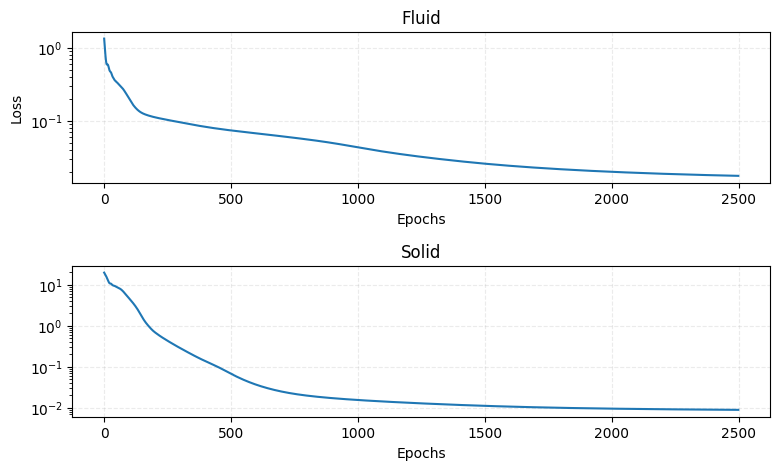

/tmp/ipykernel_2030/909681990.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  roots[i] = fsolve(func, a[i])


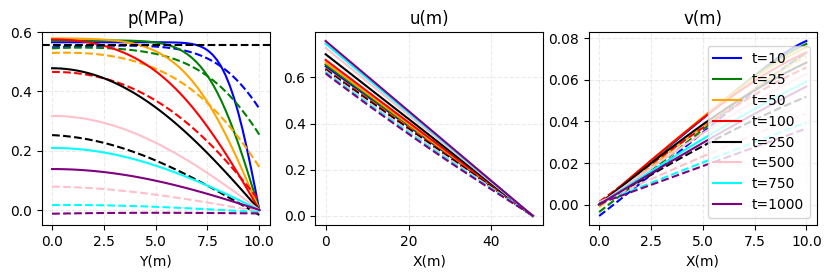

===== iteration 2/5, fluid training =====
Fluid: epoch 500/2500, Loss: 0.0266
   Weights: 1.0731, 0.9420, 1.0548, 1.0250, 0.9379, 1.0585
   Fluid Loss: 0.0054, 0.0069, 0.0001, 0.0002, 0.0125, 0.0022 
 Run Time: 42s
Fluid: epoch 1000/2500, Loss: 0.0186
   Weights: 1.0726, 0.9315, 1.0755, 1.0380, 0.9324, 1.0709
   Fluid Loss: 0.0028, 0.0052, 0.0001, 0.0001, 0.0107, 0.0005 
 Run Time: 83s
Fluid: epoch 1500/2500, Loss: 0.0169
   Weights: 1.0715, 0.9198, 1.0927, 1.0517, 0.9249, 1.0779
   Fluid Loss: 0.0025, 0.0043, 0.0000, 0.0001, 0.0106, 0.0002 
 Run Time: 125s
Fluid: epoch 2000/2500, Loss: 0.0158
   Weights: 1.0711, 0.9081, 1.1067, 1.0628, 0.9183, 1.0825
   Fluid Loss: 0.0023, 0.0046, 0.0000, 0.0001, 0.0097, 0.0002 
 Run Time: 167s
Fluid: epoch 2500/2500, Loss: 0.0154
   Weights: 1.0709, 0.8957, 1.1189, 1.0735, 0.9115, 1.0865
   Fluid Loss: 0.0023, 0.0045, 0.0000, 0.0001, 0.0095, 0.0002 
 Run Time: 208s
===== iteration 2/5, solid training =====
Solid: epoch 500/2500, Loss: 0.0083
   Weigh

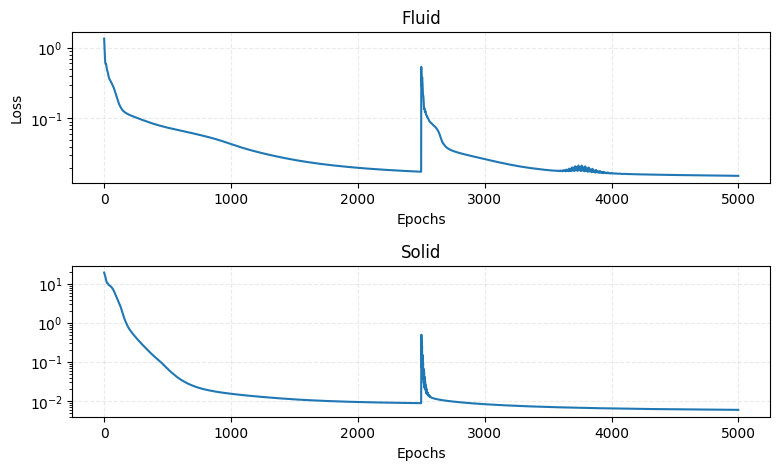

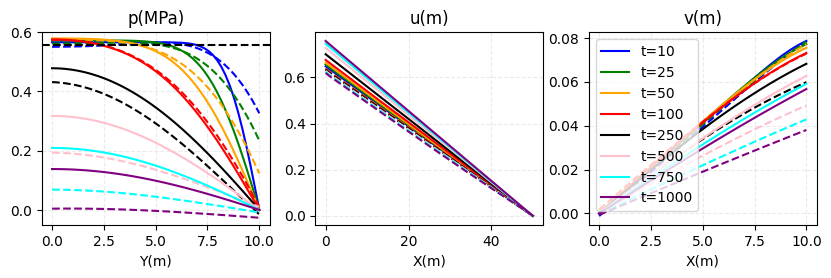

===== iteration 3/5, fluid training =====
Fluid: epoch 500/2500, Loss: 0.0147
   Weights: 1.0650, 0.8822, 1.1399, 1.0828, 0.8998, 1.0958
   Fluid Loss: 0.0016, 0.0050, 0.0000, 0.0000, 0.0092, 0.0001 
 Run Time: 42s
Fluid: epoch 1000/2500, Loss: 0.0132
   Weights: 1.0594, 0.8678, 1.1568, 1.0869, 0.8889, 1.1010
   Fluid Loss: 0.0017, 0.0041, 0.0000, 0.0000, 0.0085, 0.0001 
 Run Time: 83s
Fluid: epoch 1500/2500, Loss: 0.0121
   Weights: 1.0561, 0.8558, 1.1677, 1.0902, 0.8778, 1.1054
   Fluid Loss: 0.0015, 0.0038, 0.0000, 0.0000, 0.0080, 0.0002 
 Run Time: 125s
Fluid: epoch 2000/2500, Loss: 0.0116
   Weights: 1.0553, 0.8445, 1.1774, 1.0929, 0.8668, 1.1092
   Fluid Loss: 0.0015, 0.0037, 0.0000, 0.0000, 0.0078, 0.0002 
 Run Time: 167s
Fluid: epoch 2500/2500, Loss: 0.0112
   Weights: 1.0544, 0.8322, 1.1885, 1.0961, 0.8550, 1.1132
   Fluid Loss: 0.0015, 0.0036, 0.0000, 0.0000, 0.0076, 0.0002 
 Run Time: 208s
===== iteration 3/5, solid training =====
Solid: epoch 500/2500, Loss: 0.0047
   Weigh

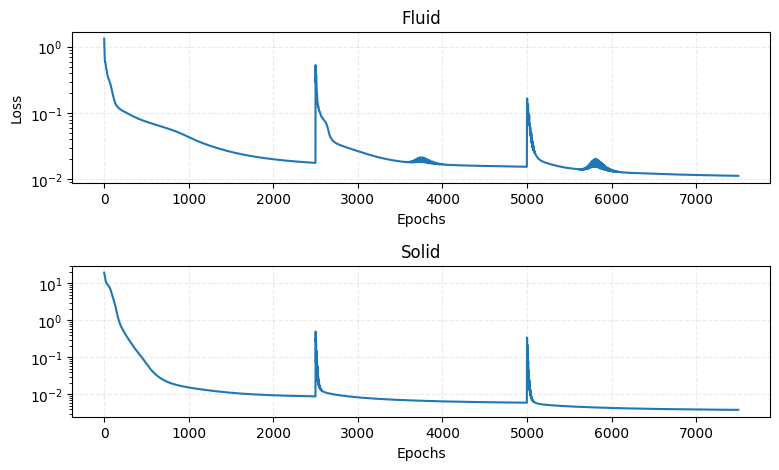

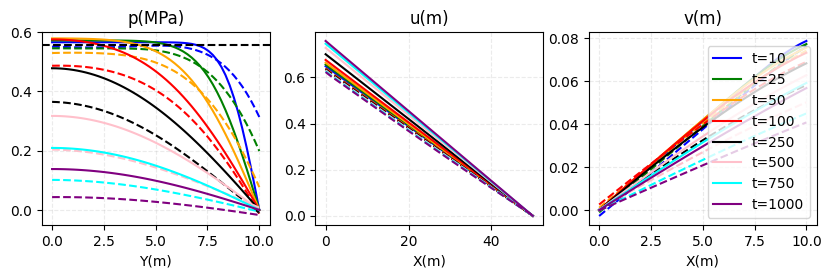

===== iteration 4/5, fluid training =====
Fluid: epoch 500/2500, Loss: 0.0128
   Weights: 1.0384, 0.8156, 1.2091, 1.1160, 0.8351, 1.1321
   Fluid Loss: 0.0020, 0.0027, 0.0000, 0.0000, 0.0098, 0.0002 
 Run Time: 42s
Fluid: epoch 1000/2500, Loss: 0.0119
   Weights: 1.0270, 0.7977, 1.2252, 1.1319, 0.8208, 1.1456
   Fluid Loss: 0.0018, 0.0068, 0.0000, 0.0001, 0.0054, 0.0001 
 Run Time: 83s
Fluid: epoch 1500/2500, Loss: 0.0094
   Weights: 1.0228, 0.7902, 1.2369, 1.1397, 0.8147, 1.1520
   Fluid Loss: 0.0010, 0.0031, 0.0000, 0.0000, 0.0069, 0.0001 
 Run Time: 125s
Fluid: epoch 2000/2500, Loss: 0.0091
   Weights: 1.0223, 0.7850, 1.2462, 1.1461, 0.8096, 1.1579
   Fluid Loss: 0.0010, 0.0030, 0.0000, 0.0000, 0.0068, 0.0001 
 Run Time: 166s
Fluid: epoch 2500/2500, Loss: 0.0089
   Weights: 1.0220, 0.7792, 1.2547, 1.1530, 0.8040, 1.1646
   Fluid Loss: 0.0010, 0.0030, 0.0000, 0.0000, 0.0068, 0.0001 
 Run Time: 208s
===== iteration 4/5, solid training =====
Solid: epoch 500/2500, Loss: 0.0036
   Weigh

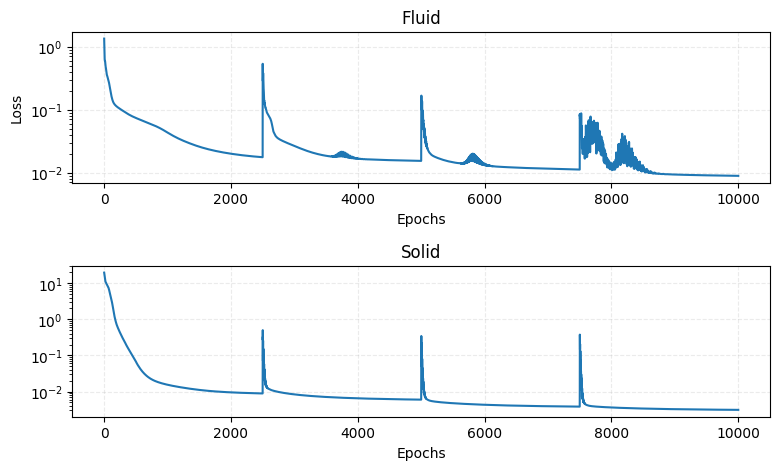

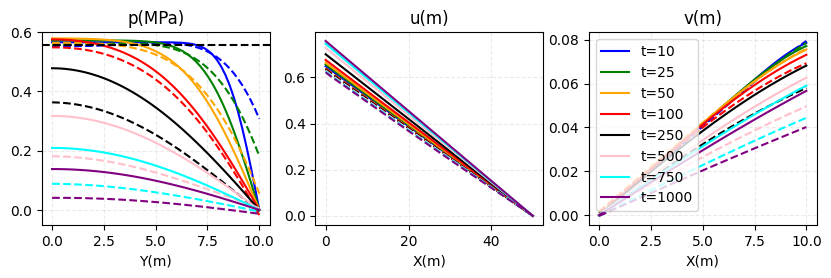

===== iteration 5/5, fluid training =====
Fluid: epoch 500/2500, Loss: 0.0416
   Weights: 1.0006, 0.7655, 1.2772, 1.1725, 0.7827, 1.1820
   Fluid Loss: 0.0120, 0.0081, 0.0000, 0.0001, 0.0289, 0.0005 
 Run Time: 41s
Fluid: epoch 1000/2500, Loss: 0.0112
   Weights: 0.9820, 0.7549, 1.2949, 1.1864, 0.7670, 1.1981
   Fluid Loss: 0.0015, 0.0024, 0.0000, 0.0000, 0.0102, 0.0001 
 Run Time: 83s
Fluid: epoch 1500/2500, Loss: 0.0086
   Weights: 0.9790, 0.7503, 1.3023, 1.1906, 0.7622, 1.2036
   Fluid Loss: 0.0010, 0.0028, 0.0000, 0.0000, 0.0070, 0.0001 
 Run Time: 125s
Fluid: epoch 2000/2500, Loss: 0.0083
   Weights: 0.9788, 0.7466, 1.3092, 1.1928, 0.7568, 1.2072
   Fluid Loss: 0.0010, 0.0027, 0.0000, 0.0000, 0.0068, 0.0001 
 Run Time: 166s
Fluid: epoch 2500/2500, Loss: 0.0081
   Weights: 0.9786, 0.7424, 1.3168, 1.1953, 0.7509, 1.2107
   Fluid Loss: 0.0010, 0.0027, 0.0000, 0.0000, 0.0068, 0.0001 
 Run Time: 208s
===== iteration 5/5, solid training =====
Solid: epoch 500/2500, Loss: 0.0030
   Weigh

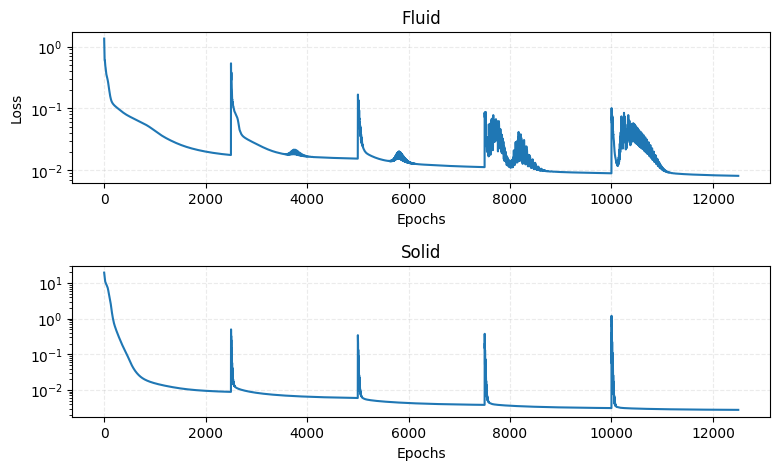

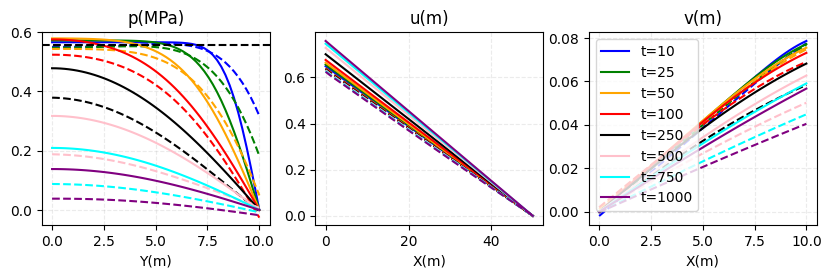

In [28]:
alpha = 0.5
# total_points = 25000
num_batch = 1
GN_Freq = 10
Plot_Freq = 500
n_iter = 5

def freeze(model): # stop training
  for j in model.parameters():
    j.requires_grad_(False)

def unfreeze(model): # ready from training
  for j in model.parameters():
    j.requires_grad_(True)

def grad_cal(y, x):
  grad = torch.autograd.grad(y, x, torch.ones_like(y), retain_graph=True, create_graph=True, allow_unused=True)[0]
  if grad is None:
    grad = torch.zeros_like(x)

  return grad
# def All_Derivatives():

His_L_S, His_L_F = [], []
for iter in range(n_iter):
  Opt_F = torch.optim.Adam(model_pd.parameters(), lr=initial_lr)
  Scheduler_F = torch.optim.lr_scheduler.ExponentialLR(Opt_F, gamma=gamma)
  Opt_GN_F = torch.optim.Adam((W_F_Eq, W_F_ic, W_F_bcr, W_F_bcl, W_F_bct, W_F_bcb), lr=0.5e-3)


  Opt_S = torch.optim.Adam(list(model_ud.parameters())+list(model_vd.parameters()), lr=initial_lr)
  Scheduler_S = torch.optim.lr_scheduler.ExponentialLR(Opt_S, gamma=gamma)
  Opt_GN_S = torch.optim.Adam((W_S_u_Eq, W_S_v_Eq, W_S_IC_Sxx, W_S_IC_Syy, W_S_BCL_u, W_S_BCR_u, W_S_BCB_u, W_S_BCT_u, W_S_BCL_v, W_S_BCR_v, W_S_BCB_v, W_S_BCT_v), lr=0.5e-3)

  # ========================= #
  # ==== Fluid Training ===== #
  print("===== iteration {}/{}, fluid training =====".format(iter+1, n_iter))
  unfreeze(model_pd), freeze(model_ud),freeze(model_vd)
  start_time = time.time()
  for epoch in range(num_epochs):
    for batch in range(num_batch):
      Opt_F.zero_grad(), Opt_GN_F.zero_grad()

      xd_dom, yd_dom, td_dom, xd_ic, yd_ic, td_ic, xd_bcr, yd_bcr, td_bcr, xd_bcl, yd_bcl, td_bcl, xd_bcb, yd_bcb, td_bcb, xd_bct, yd_bct, td_bct = sample_points() #total_points
      pd_dom, pd_ic, pd_bcr, pd_bcl, pd_bcb, pd_bct, ud_dom, vd_dom, Evd_dom, Sxxd_ic, Syyd_ic, Sxxd_bcl, ud_bcr, Sxyd_bcb, Sxyd_bct, Sxyd_bcl, Sxyd_bcr, vd_bcb, Syyd_bct, Svd_td_dom = All_Derivatives(xd_dom, yd_dom, td_dom, xd_ic, yd_ic, td_ic, xd_bcr, yd_bcr, td_bcr, xd_bcl, yd_bcl, td_bcl, xd_bcb, yd_bcb, td_bcb, xd_bct, yd_bct, td_bct)

      L_p_Eq = torch.mean((grad_cal(pd_dom,td_dom) - grad_cal(grad_cal(pd_dom, xd_dom), xd_dom) - grad_cal(grad_cal(pd_dom, yd_dom), yd_dom) + D_star*Svd_td_dom.detach())**2)
      L_p_ic = torch.mean((pd_ic-1.0)**2)
      L_p_bcr = torch.mean((grad_cal(pd_bcr, xd_bcr))**2)
      L_p_bcl = torch.mean((grad_cal(pd_bcl, xd_bcl))**2)
      L_p_bct = torch.mean((pd_bct)**2)
      L_p_bcb = torch.mean((grad_cal(pd_bcb, yd_bcb))**2)


      Losses_F = torch.stack([L_p_Eq, L_p_ic, L_p_bcr, L_p_bcl, L_p_bct, L_p_bcb])

      if epoch == 0:
        L_i_0 = Losses_F.detach()
      if epoch % GN_Freq == int(GN_Freq-1) or epoch ==0:
        L_i_t = [L_p_Eq, L_p_ic, L_p_bcr, L_p_bcl, L_p_bct, L_p_bcb]
        LB_i_t = [L_i_t[i] / L_i_0[i] for i in range(len(L_i_t))]
        LB_i_t_avg = torch.stack(LB_i_t).mean()

        R_i_t = [(LB_i_t[i]/LB_i_t_avg).detach() for i in range(len(L_i_t))]
        W_F = torch.stack([W_F_Eq, W_F_ic, W_F_bcr, W_F_bcl, W_F_bct, W_F_bcb])
        G_i_t = [W_F[i]*torch.norm(grad_cal(L_i_t[i], LL_pd), p=2) for i in range(len(L_i_t))]
        G_i_t_avg = torch.stack(G_i_t).mean()
        GS_i_t = [(R_i_t[i]**alpha)*G_i_t_avg.detach() for i in range(len(R_i_t))]
        L_GN_F = torch.sum(torch.abs(torch.stack(G_i_t) - torch.stack(GS_i_t).reshape(-1,1)))

        L_GN_F.backward(retain_graph=True)


      Opt_F.zero_grad()

      L_F = (W_F.detach().flatten()*Losses_F).sum() #Losses_F.sum() #
      L_F_epoch = L_F.item()
      His_L_F.append(L_F_epoch)
      L_F.backward()

      if epoch % GN_Freq == int(GN_Freq-1) or epoch == 0:
        Opt_GN_F.step()

      Opt_F.step()
      Scheduler_F.step()

    if epoch % Plot_Freq == int(Plot_Freq-1):
      print(f"Fluid: epoch {epoch+1}/{num_epochs}, Loss: {L_F_epoch:.4f}\n   Weights: {', '.join(f'{w.item():.4f}' for w in W_F)}"
         f"\n   Fluid Loss: {', '.join(f'{l.item():.4f}' for l in Losses_F)} \n Run Time: {time.time()-start_time:.0f}s")


  # ========================= #
  # ==== Solid Training ===== #
  print("===== iteration {}/{}, solid training =====".format(iter+1, n_iter))
  freeze(model_pd), unfreeze(model_ud),unfreeze(model_vd)
  start_time = time.time()
  for epoch in range(num_epochs):
    for batch in range(num_batch):
      Opt_S.zero_grad(), Opt_GN_S.zero_grad()
      xd_dom, yd_dom, td_dom, xd_ic, yd_ic, td_ic, xd_bcr, yd_bcr, td_bcr, xd_bcl, yd_bcl, td_bcl, xd_bcb, yd_bcb, td_bcb, xd_bct, yd_bct, td_bct = sample_points(total_points)
      pd_dom, pd_ic, pd_bcr, pd_bcl, pd_bcb, pd_bct, ud_dom, vd_dom, Evd_dom, Sxxd_ic, Syyd_ic, Sxxd_bcl, ud_bcr, Sxyd_bcb, Sxyd_bct, Sxyd_bcl, Sxyd_bcr, vd_bcb, Syyd_bct, Svd_td_dom = All_Derivatives(xd_dom, yd_dom, td_dom, xd_ic, yd_ic, td_ic, xd_bcr, yd_bcr, td_bcr, xd_bcl, yd_bcl, td_bcl, xd_bcb, yd_bcb, td_bcb, xd_bct, yd_bct, td_bct)

      L_u_Eq = torch.mean((grad_cal(Evd_dom, xd_dom)  + 1.5*nu_star*grad_cal(grad_cal(ud_dom, xd_dom), xd_dom) + \
        grad_cal(grad_cal(ud_dom, yd_dom), yd_dom) + (nu_star/2)*grad_cal(grad_cal(ud_dom, xd_dom)+grad_cal(vd_dom, yd_dom), xd_dom)- \
        b*grad_cal(pd_dom, xd_dom))**2)
      L_v_Eq = torch.mean((grad_cal(Evd_dom, yd_dom)  + 1.5*nu_star*(grad_cal(grad_cal(vd_dom, xd_dom), xd_dom) + grad_cal(grad_cal(vd_dom,yd_dom), yd_dom)) +\
                  (nu_star/2)*grad_cal(Evd_dom, yd_dom)  - b*grad_cal(pd_dom, yd_dom))**2)


      ## --- BC --- ##
      L_IC_Sxx = torch.mean((Sxxd_ic-S_overburden/p_star)**2)
      L_IC_Syy = torch.mean((Syyd_ic)**2)

      L_BCL_u = torch.mean((Sxxd_bcl - S_overburden/p_star)**2)
      L_BCR_u = torch.mean((ud_bcr)**2)
      L_BCB_u = torch.mean((Sxyd_bcb)**2)
      L_BCT_u = torch.mean((Sxyd_bct)**2)

      L_BCL_v = torch.mean((Sxyd_bcl)**2)
      L_BCR_v = torch.mean((Sxyd_bcr)**2)
      L_BCB_v = torch.mean((vd_bcb)**2)
      L_BCT_v = torch.mean((Syyd_bct)**2)
      Losses_S = torch.stack([L_u_Eq, L_v_Eq, L_IC_Sxx, L_IC_Syy, L_BCL_u, L_BCR_u, L_BCB_u, L_BCT_u, L_BCL_v, L_BCR_v, L_BCB_v, L_BCT_v])

      if epoch == 0:
        L_i_0 = Losses_S.detach()
      if epoch%GN_Freq == int(GN_Freq-1) or epoch ==0:
        L_i_t = [L_u_Eq, L_v_Eq, L_IC_Sxx, L_IC_Syy, L_BCL_u, L_BCR_u, L_BCB_u, L_BCT_u, L_BCL_v, L_BCR_v, L_BCB_v, L_BCT_v]
        LB_i_t = [L_i_t[i] / L_i_0[i] for i in range(len(L_i_t))]
        LB_i_t_avg = torch.stack(LB_i_t).mean()

        R_i_t = [(LB_i_t[i]/LB_i_t_avg).detach() for i in range(len(L_i_t))]
        W_S = torch.stack([W_S_u_Eq, W_S_v_Eq, W_S_IC_Sxx, W_S_IC_Syy, W_S_BCL_u, W_S_BCR_u, W_S_BCB_u, W_S_BCT_u, W_S_BCL_v, W_S_BCR_v, W_S_BCB_v, W_S_BCT_v])
        G_i_t = [W_S[i]*(torch.norm(0.5*grad_cal(L_i_t[i], LL_ud), p=2)+torch.norm(0.5*grad_cal(L_i_t[i],LL_vd), p=2)) for i in range(len(L_i_t))]
        G_i_t_avg = torch.stack(G_i_t).mean()
        GS_i_t = [(R_i_t[i]**alpha)*G_i_t_avg.detach() for i in range(len(R_i_t))]
        L_GN_S = torch.sum(torch.abs(torch.stack(G_i_t) - torch.stack(GS_i_t).reshape(-1,1)))

        L_GN_S.backward(retain_graph=True)

      Opt_S.zero_grad()

      L_S = (W_S.detach().flatten()*Losses_S).sum() #Losses_S.sum() #
      L_S_epoch = L_S.item()
      His_L_S.append(L_S_epoch)
      L_S.backward()

      if epoch % GN_Freq == int(GN_Freq-1) or epoch == 0:
        Opt_GN_S.step()

      Opt_S.step()
      Scheduler_S.step()

    if epoch % Plot_Freq == int(Plot_Freq-1):
      print(f"Solid: epoch {epoch+1}/{num_epochs}, Loss: {L_S_epoch:.4f}\n   Weights: {', '.join(f'{w.item():.4f}' for w in W_S)}"
         f"\n   Solid Loss: {', '.join(f'{l.item():.4f}' for l in Losses_S)} \n Run Time: {time.time()-start_time:.0f}s")




  print(f"\n======== plot results for iteration {iter+1}/{n_iter} ==========\n")
  plot_function(His_L_F, His_L_S, model_pd, model_ud, model_vd)
